# Bibliotecas

In [182]:
import pandas as pd
import numpy as np
import sklearn
import keras
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import MinMaxScaler

from keras.layers import Input, Dropout, Dense, BatchNormalization
from keras.models import Sequential
from keras import regularizers
from keras.callbacks import EarlyStopping

# Questão 2

## Divisão do conjunto de treino em treino e validação

In [183]:
treino = pd.read_csv('train.csv')
teste = pd.read_csv('test.csv')

treino, validacao = train_test_split(treino, random_state=42, test_size=0.2)

## Análise exploratória dos dados

In [184]:
treino

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
331,332,0,1,"Partner, Mr. Austen",male,45.5,0,0,113043,28.5000,C124,S
733,734,0,2,"Berriman, Mr. William John",male,23.0,0,0,28425,13.0000,NaN,S
382,383,0,3,"Tikkanen, Mr. Juho",male,32.0,0,0,STON/O 2. 3101293,7.9250,NaN,S
704,705,0,3,"Hansen, Mr. Henrik Juul",male,26.0,1,0,350025,7.8542,NaN,S
813,814,0,3,"Andersson, Miss. Ebba Iris Alfrida",female,6.0,4,2,347082,31.2750,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
106,107,1,3,"Salkjelsvik, Miss. Anna Kristine",female,21.0,0,0,343120,7.6500,NaN,S
270,271,0,1,"Cairns, Mr. Alexander",male,NaN,0,0,113798,31.0000,NaN,S
860,861,0,3,"Hansen, Mr. Claus Peter",male,41.0,2,0,350026,14.1083,NaN,S
435,436,1,1,"Carter, Miss. Lucile Polk",female,14.0,1,2,113760,120.0000,B96 B98,S


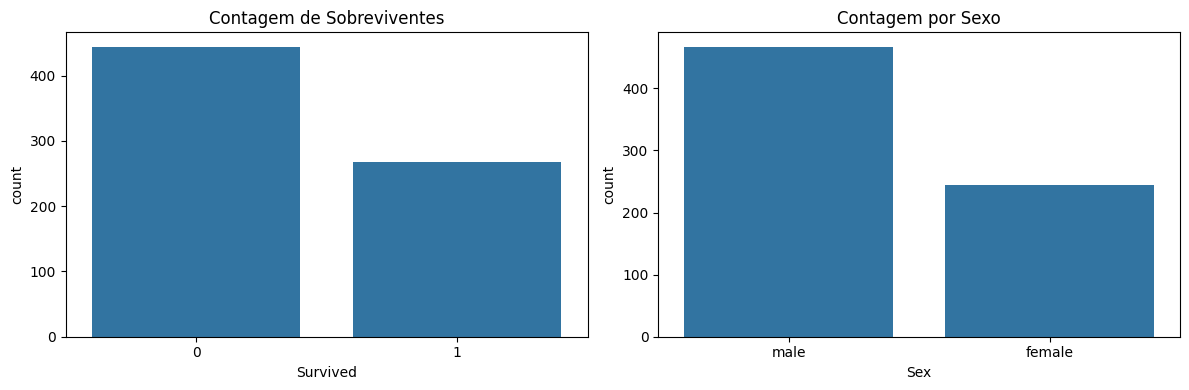

In [185]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x='Survived', data=treino, ax=axes[0])
axes[0].set_title('Contagem de Sobreviventes')

sns.countplot(x='Sex', data=treino, ax=axes[1])
axes[1].set_title('Contagem por Sexo')

plt.tight_layout()
plt.show()

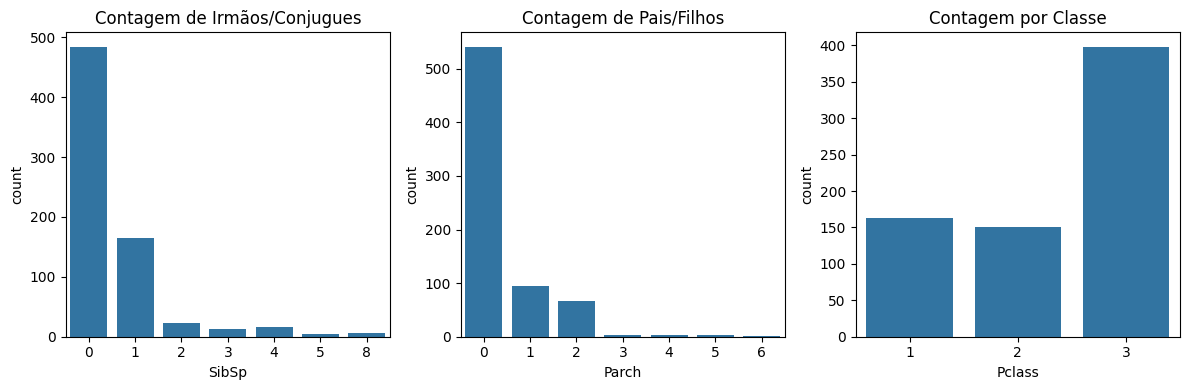

In [186]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

sns.countplot(x='SibSp', data=treino, ax=axes[0])
axes[0].set_title('Contagem de Irmãos/Conjugues')

sns.countplot(x='Parch', data=treino, ax=axes[1])
axes[1].set_title('Contagem de Pais/Filhos')

sns.countplot(x='Pclass', data=treino, ax=axes[2])
axes[2].set_title('Contagem por Classe')

plt.tight_layout()
plt.show()

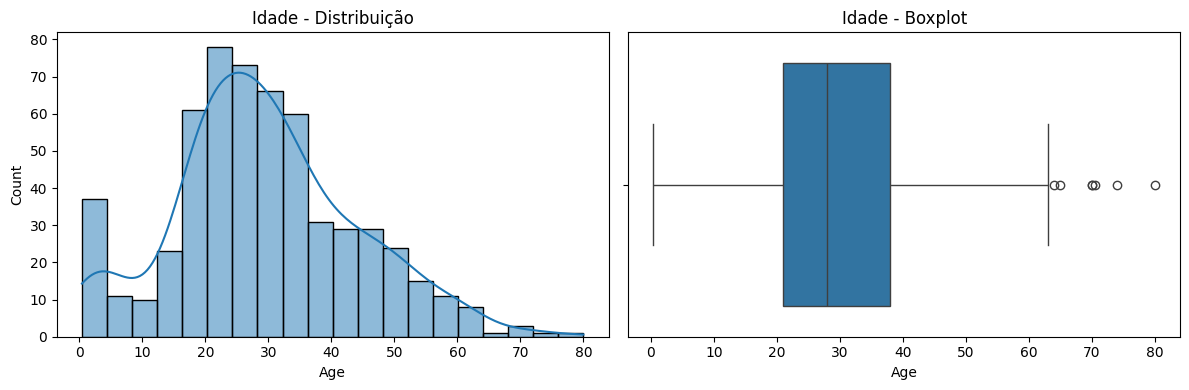

In [187]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(treino['Age'], ax=axes[0], kde=True)
axes[0].set_title('Idade - Distribuição')

sns.boxplot(x=treino['Age'], ax=axes[1])
axes[1].set_title('Idade - Boxplot')

plt.tight_layout()
plt.show()

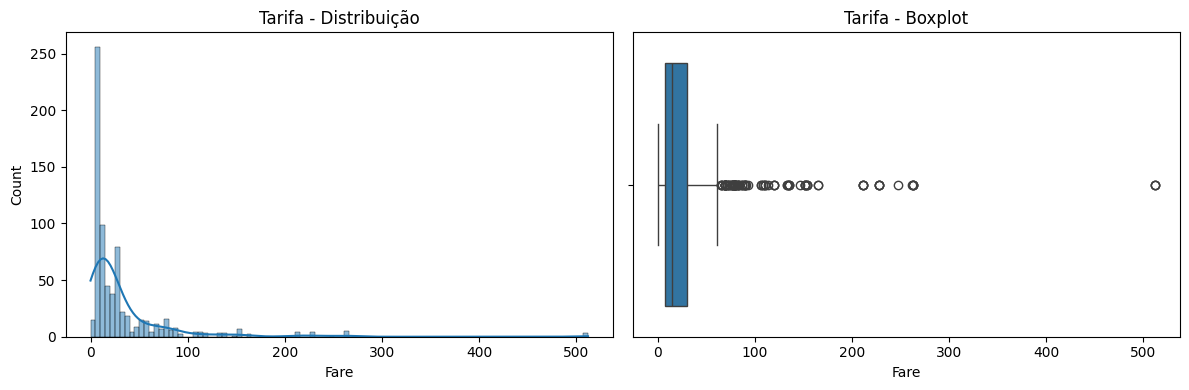

In [188]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(treino['Fare'], ax=axes[0], kde=True)
axes[0].set_title('Tarifa - Distribuição')

sns.boxplot(x=treino['Fare'], ax=axes[1])
axes[1].set_title('Tarifa - Boxplot')

plt.tight_layout()
plt.show()

In [189]:
validacao

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
709,710,1,3,"Moubarek, Master. Halim Gonios (""William George"")",male,NaN,1,1,2661,15.2458,NaN,C
439,440,0,2,"Kvillner, Mr. Johan Henrik Johannesson",male,31.0,0,0,C.A. 18723,10.5000,NaN,S
840,841,0,3,"Alhomaki, Mr. Ilmari Rudolf",male,20.0,0,0,SOTON/O2 3101287,7.9250,NaN,S
720,721,1,2,"Harper, Miss. Annie Jessie ""Nina""",female,6.0,0,1,248727,33.0000,NaN,S
39,40,1,3,"Nicola-Yarred, Miss. Jamila",female,14.0,1,0,2651,11.2417,NaN,C
...,...,...,...,...,...,...,...,...,...,...,...,...
433,434,0,3,"Kallio, Mr. Nikolai Erland",male,17.0,0,0,STON/O 2. 3101274,7.1250,NaN,S
773,774,0,3,"Elias, Mr. Dibo",male,NaN,0,0,2674,7.2250,NaN,C
25,26,1,3,"Asplund, Mrs. Carl Oscar (Selma Augusta Emilia...",female,38.0,1,5,347077,31.3875,NaN,S
84,85,1,2,"Ilett, Miss. Bertha",female,17.0,0,0,SO/C 14885,10.5000,NaN,S


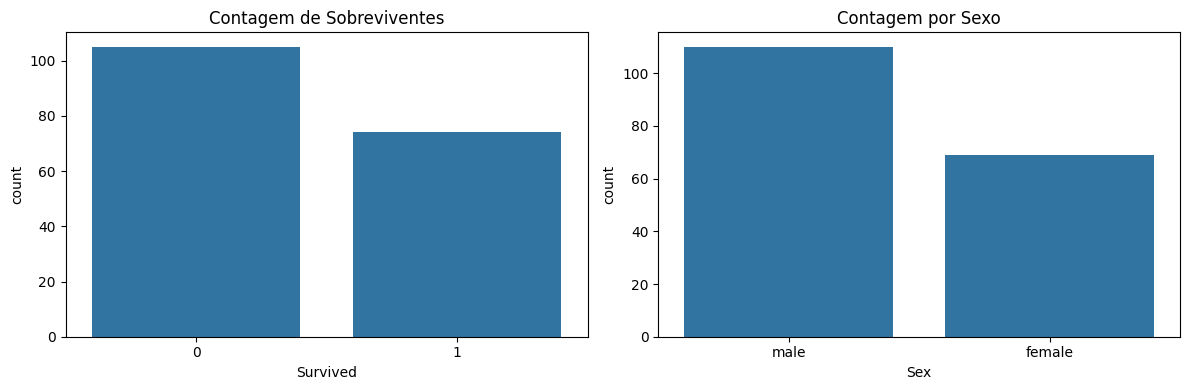

In [190]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x='Survived', data=validacao, ax=axes[0])
axes[0].set_title('Contagem de Sobreviventes')

sns.countplot(x='Sex', data=validacao, ax=axes[1])
axes[1].set_title('Contagem por Sexo')

plt.tight_layout()
plt.show()

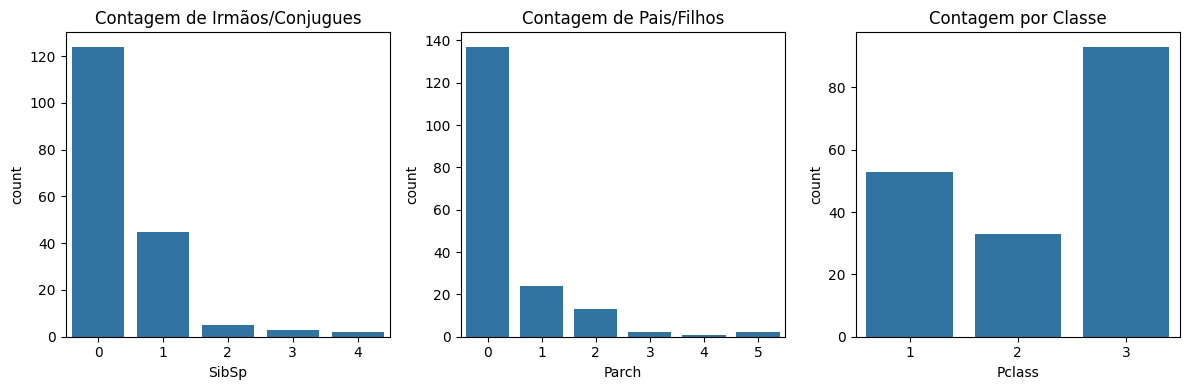

In [191]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

sns.countplot(x='SibSp', data=validacao, ax=axes[0])
axes[0].set_title('Contagem de Irmãos/Conjugues')

sns.countplot(x='Parch', data=validacao, ax=axes[1])
axes[1].set_title('Contagem de Pais/Filhos')

sns.countplot(x='Pclass', data=validacao, ax=axes[2])
axes[2].set_title('Contagem por Classe')

plt.tight_layout()
plt.show()

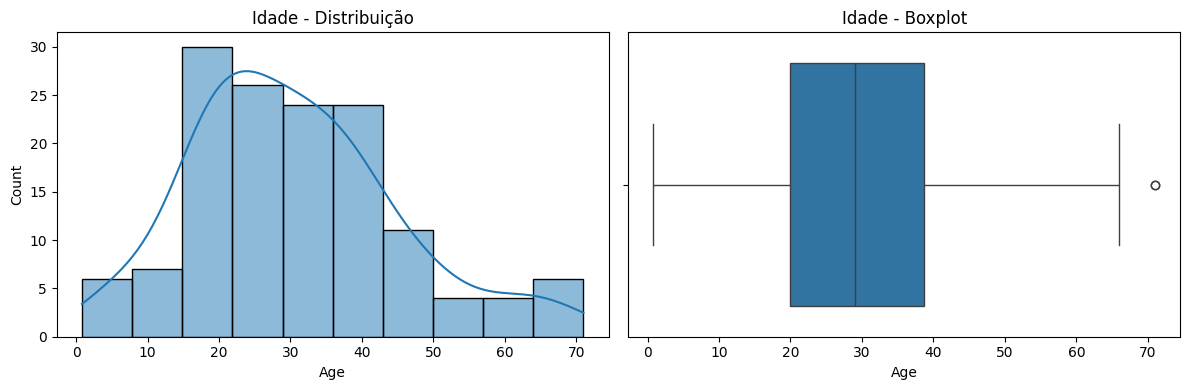

In [192]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(validacao['Age'], ax=axes[0], kde=True)
axes[0].set_title('Idade - Distribuição')

sns.boxplot(x=validacao['Age'], ax=axes[1])
axes[1].set_title('Idade - Boxplot')

plt.tight_layout()
plt.show()

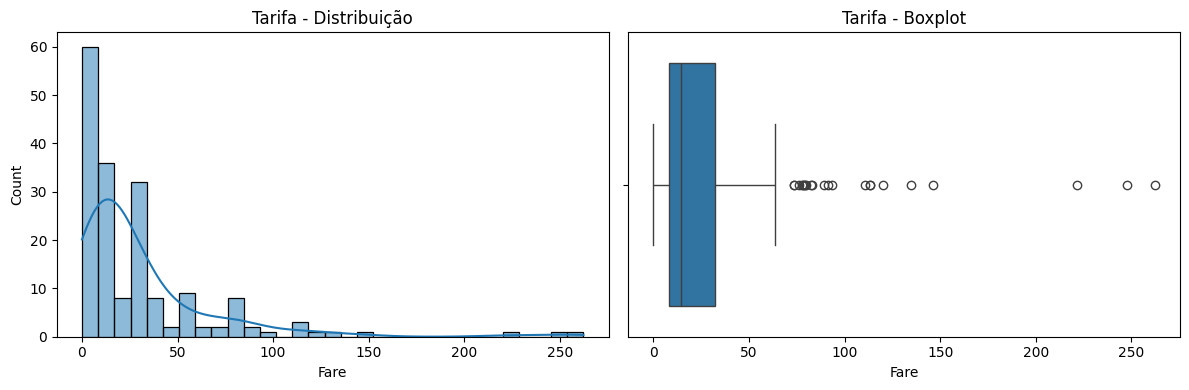

In [193]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(validacao['Fare'], ax=axes[0], kde=True)
axes[0].set_title('Tarifa - Distribuição')

sns.boxplot(x=validacao['Fare'], ax=axes[1])
axes[1].set_title('Tarifa - Boxplot')

plt.tight_layout()
plt.show()

In [194]:
teste

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


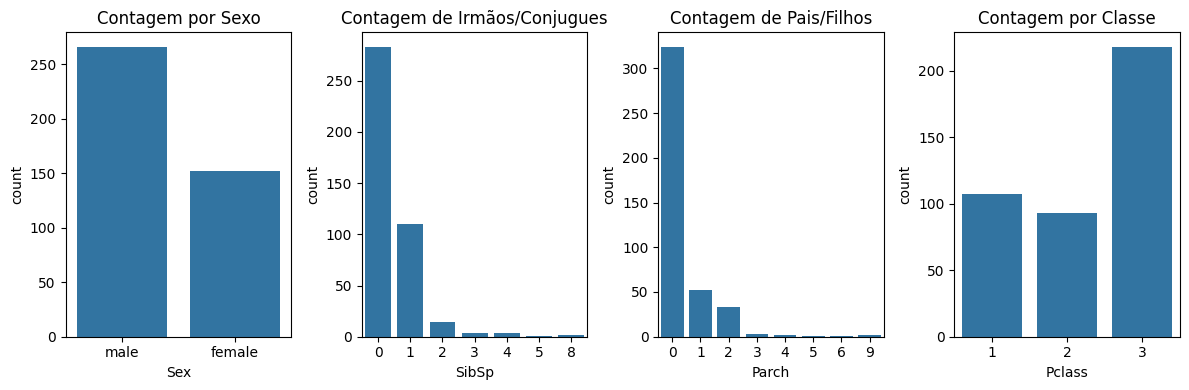

In [195]:
fig, axes = plt.subplots(1, 4, figsize=(12, 4))

sns.countplot(x='Sex', data=teste, ax=axes[0])
axes[0].set_title('Contagem por Sexo')

sns.countplot(x='SibSp', data=teste, ax=axes[1])
axes[1].set_title('Contagem de Irmãos/Conjugues')

sns.countplot(x='Parch', data=teste, ax=axes[2])
axes[2].set_title('Contagem de Pais/Filhos')

sns.countplot(x='Pclass', data=teste, ax=axes[3])
axes[3].set_title('Contagem por Classe')

plt.tight_layout()
plt.show()

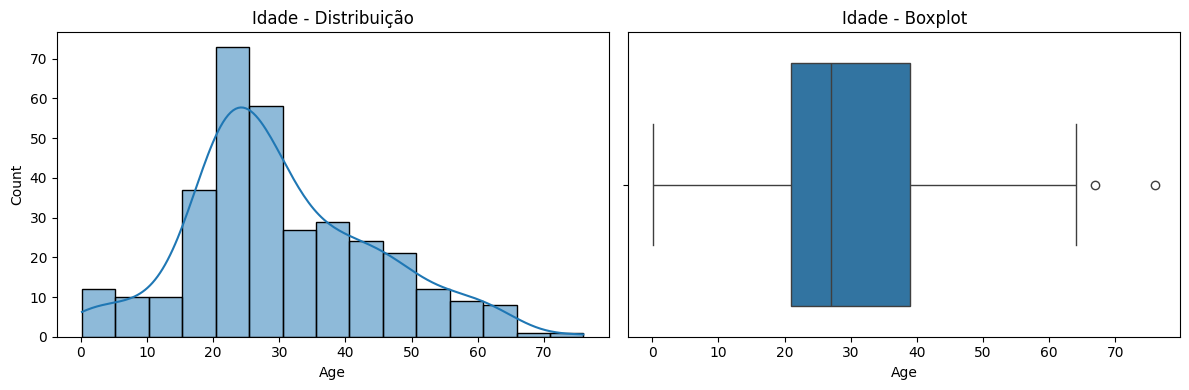

In [196]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(teste['Age'], ax=axes[0], kde=True)
axes[0].set_title('Idade - Distribuição')

sns.boxplot(x=teste['Age'], ax=axes[1])
axes[1].set_title('Idade - Boxplot')

plt.tight_layout()
plt.show()

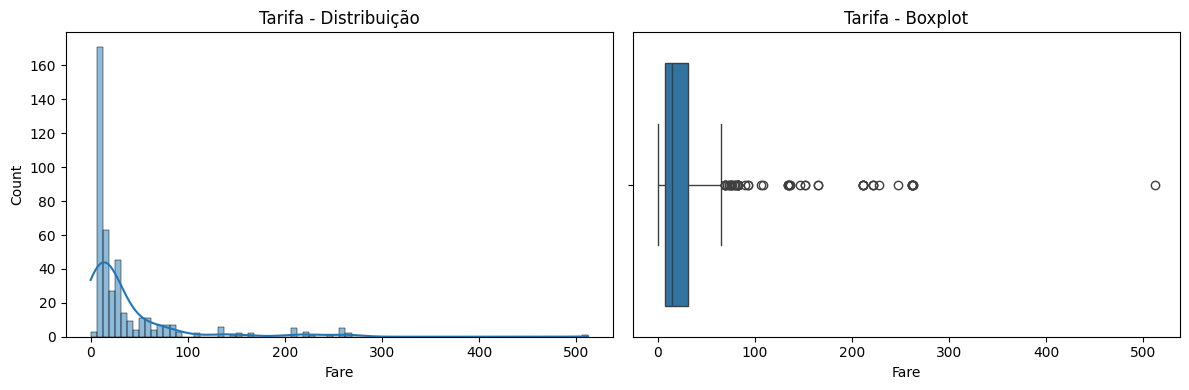

In [197]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(teste['Fare'], ax=axes[0], kde=True)
axes[0].set_title('Tarifa - Distribuição')

sns.boxplot(x=teste['Fare'], ax=axes[1])
axes[1].set_title('Tarifa - Boxplot')

plt.tight_layout()
plt.show()

## Identificação de valores ausentes

In [198]:
ausentes_treino = treino.isnull().sum()
pct_ausentes_treino = (ausentes_treino / len(treino)) * 100

pct_ausentes_treino_df = pd.DataFrame({'Coluna': ausentes_treino.index, 'Ausentes': ausentes_treino.values, 'Porcentagem': pct_ausentes_treino.values}).query('Ausentes > 0')
pct_ausentes_treino_df

,Coluna,Ausentes,Porcentagem
5,Age,140,19.662921
10,Cabin,553,77.668539
11,Embarked,2,0.280899


In [199]:
ausentes_validacao = validacao.isnull().sum()
pct_ausentes_validacao = (ausentes_validacao / len(validacao)) * 100

pct_ausentes_validacao_df = pd.DataFrame({'Coluna': ausentes_validacao.index, 'Ausentes': ausentes_validacao.values, 'Porcentagem': pct_ausentes_validacao.values}).query('Ausentes > 0')
pct_ausentes_validacao_df

,Coluna,Ausentes,Porcentagem
5,Age,37,20.670391
10,Cabin,134,74.860335


In [200]:
ausentes_teste = teste.isnull().sum()
pct_ausentes_teste = (ausentes_teste / len(teste)) * 100

pct_ausentes_teste_df = pd.DataFrame({'Coluna': ausentes_teste.index, 'Ausentes': ausentes_teste.values, 'Porcentagem': pct_ausentes_teste.values}).query('Ausentes > 0')
pct_ausentes_teste_df

,Coluna,Ausentes,Porcentagem
4,Age,86,20.574163
8,Fare,1,0.239234
9,Cabin,327,78.229665


## Tratamento de dados faltantes

In [201]:
# removendo a coluna 'Cabin' dos datasets de treino e teste

treino_limpo = treino.drop(columns=['Cabin'])
validacao_limpo = validacao.drop(columns=['Cabin'])
teste_limpo = teste.drop(columns=['Cabin'])

# preenchendo os valores ausentes da coluna 'Age' no treino e no teste com a mediana da idade do treino

idade_mediana = treino_limpo['Age'].median()

treino_limpo['Age'] = treino_limpo['Age'].fillna(idade_mediana)
validacao_limpo['Age'] = validacao_limpo['Age'].fillna(idade_mediana)
teste_limpo['Age'] = teste_limpo['Age'].fillna(idade_mediana)

# preenchendo os valores ausentes da coluna 'Embarked' com a moda do treino

treino_limpo['Embarked'] = treino_limpo['Embarked'].fillna(treino_limpo['Embarked'].mode()[0])

# preenchendo os valores ausentes da coluna 'Fare' no teste com a mediana da tarifa do treino

tarifa_mediana = treino_limpo['Fare'].median()

teste_limpo['Fare'] = teste_limpo['Fare'].fillna(tarifa_mediana)

# aplicando a transformação logarítmica na coluna 'Fare' para reduzir a assimetria da distribuição

treino_limpo['Fare'] = np.log1p(treino_limpo['Fare'])
validacao_limpo['Fare'] = np.log1p(validacao_limpo['Fare'])
teste_limpo['Fare']  = np.log1p(teste_limpo['Fare'])

## Análise de atributos irrelevantes ou redundantes

In [202]:
treino_limpo = treino_limpo.drop(columns=['PassengerId', 'Name', 'Ticket'])
validacao_limpo = validacao_limpo.drop(columns=['PassengerId', 'Name', 'Ticket'])
teste_limpo = teste_limpo.drop(columns=['PassengerId', 'Name', 'Ticket'])

## Transformação de atributos categóricos

In [203]:
# transformando a coluna 'Sex' em binária (0 para feminino e 1 para masculino)

treino_limpo['Sex']  = treino_limpo['Sex'].map({'male': 1, 'female': 0})
validacao_limpo['Sex']  = validacao_limpo['Sex'].map({'male': 1, 'female': 0})
teste_limpo['Sex']  = teste_limpo['Sex'].map({'male': 1, 'female': 0})

# aplicando one-hot encoding na coluna 'Embarked'

treino_limpo = pd.get_dummies(treino_limpo, columns=['Embarked']).astype({'Embarked_C': int, 'Embarked_Q': int, 'Embarked_S': int})
validacao_limpo  = pd.get_dummies(validacao_limpo,  columns=['Embarked']).astype({'Embarked_C': int, 'Embarked_Q': int, 'Embarked_S': int})
teste_limpo  = pd.get_dummies(teste_limpo,  columns=['Embarked']).astype({'Embarked_C': int, 'Embarked_Q': int, 'Embarked_S': int})

## Conversão dos DataFrames em arrays numpy

In [204]:
X_treino = np.array(treino_limpo.drop(['Survived'], axis = 1))
y_treino = np.array(treino['Survived'])

X_val = np.array(validacao_limpo.drop(['Survived'], axis = 1))
y_val = np.array(validacao_limpo['Survived'])

X_teste = np.array(teste_limpo)

print(f"Quantidade de amostras para treino: {X_treino.shape[0]}")
print(f"Quantidade de amostras para validação: {X_val.shape[0]}")
print(f"Quantidade de amostras para teste: {X_teste.shape[0]}")

Quantidade de amostras para treino: 712
Quantidade de amostras para validação: 179
Quantidade de amostras para teste: 418


## Normalização ou padronização dos atributos numéricos

In [205]:
stat, p = stats.normaltest(treino_limpo['Age'].dropna())

print(f'Estatística: {stat:.4f}')
print(f'P-valor: {p:.4f}')

if p > 0.05:
    print('Os valores da coluna "Age" seguem distribuição normal')
else:
    print('Os valores da coluna "Age" não seguem distribuição normal')

Estatística: 34.9714
P-valor: 0.0000
Os valores da coluna "Age" não seguem distribuição normal


In [206]:
scaler = MinMaxScaler()

X_treino = scaler.fit_transform(X_treino)
X_val = scaler.transform(X_val)
X_teste = scaler.transform(X_teste)

## Arquitetura da rede neural simples de 2 camadas densas

In [222]:
model1 = Sequential()

model1.add(Input(shape=(9,)))

model1.add(Dense(4, kernel_initializer='he_normal', activation='relu'))

model1.add(Dense(4, kernel_initializer='he_normal', activation='relu'))

model1.add(Dense(1, kernel_initializer='he_normal', activation='sigmoid'))

initial_weights = model1.get_weights()

model1.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

print(model1.summary())

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_48 (Dense)                │ (None, 4)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65 (260.00 B)

 Trainable params: 65 (260.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [223]:
model1.set_weights(initial_weights)
history = model1.fit(X_treino, y_treino, epochs=200, batch_size=16, validation_data=(X_val, y_val))

Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.5267 - loss: 0.6844 - val_accuracy: 0.6872 - val_loss: 0.6480
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7163 - loss: 0.6560 - val_accuracy: 0.7654 - val_loss: 0.6316
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7486 - loss: 0.6398 - val_accuracy: 0.7709 - val_loss: 0.6186
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7219 - loss: 0.6260 - val_accuracy: 0.7263 - val_loss: 0.6056
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7177 - loss: 0.6128 - val_accuracy: 0.7263 - val_loss: 0.5940
Epoch 6/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7177 - loss: 0.6001 - val_accuracy: 0.7430 - val_loss: 0.5816
Epoch 7/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7135 - loss: 0.5875 - val_accuracy: 0.7374 - val_loss: 0.5688
Epoch 8/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7135 - loss: 0.5749 - val_accuracy: 0.7318 -

### Curva de erro de treinamento e validação

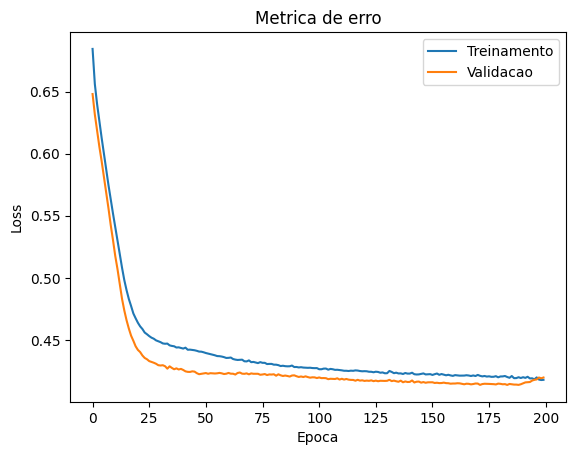


-> Loss_treino = 0.4164
-> Loss_val = 0.4198
-> Loss_val - Loss_treino = 0.0034

-> E_in = 0.1756
-> E_val = 0.1844
-> E_val - E_in = 0.0088

-> Acc_treino: 0.8244
-> Acc_val: 0.8156
-> Acc_treino - Acc_val = 0.0088


In [224]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Metrica de erro')
plt.ylabel('Loss')
plt.xlabel('Epoca')
plt.legend(['Treinamento', 'Validacao'])
plt.show()

loss_train, acc_train = model1.evaluate(X_treino, y_treino, batch_size=16, verbose=0)

loss_val, acc_val = model1.evaluate(X_val, y_val, batch_size=16, verbose=0)

e_in = 1 - acc_train
e_val = 1 - acc_val

print(f"\n-> Loss_treino = {loss_train:.4f}")
print(f"-> Loss_val = {loss_val:.4f}")
print(f"-> Loss_val - Loss_treino = {loss_val - loss_train:.4f}\n")

print(f"-> E_in = {e_in:.4f}")
print(f"-> E_val = {e_val:.4f}")
print(f"-> E_val - E_in = {e_val - e_in:.4f}\n")

print(f'-> Acc_treino: {acc_train:.4f}')
print(f'-> Acc_val: {acc_val:.4f}')
print(f"-> Acc_treino - Acc_val = {acc_train - acc_val:.4f}")

### Matriz de confusão

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


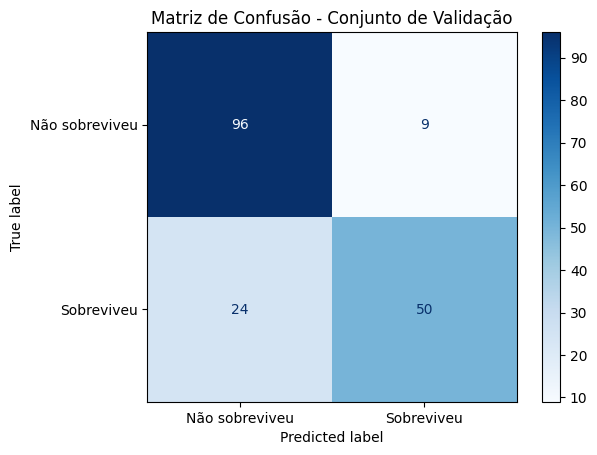

In [225]:
y_pred_val = (model1.predict(X_val) > 0.5).astype(int).flatten()

cm = confusion_matrix(y_val, y_pred_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Não sobreviveu', 'Sobreviveu'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão - Conjunto de Validação')
plt.show()

### Métricas de erro

In [226]:
acc = accuracy_score(y_val, y_pred_val)
prec = precision_score(y_val, y_pred_val)
rec = recall_score(y_val, y_pred_val)
f1 = f1_score(y_val, y_pred_val)

print(f"-> Accuracy: {acc:.4f}")
print(f"-> Precision: {prec:.4f}")
print(f"-> Recall: {rec:.4f}")
print(f"-> F1-score: {f1:.4f}\n")

print("Relatório de classificação completo:")
print(classification_report(y_val, y_pred_val, target_names=['Não sobreviveu', 'Sobreviveu']))

-> Accuracy: 0.8156
-> Precision: 0.8475
-> Recall: 0.6757
-> F1-score: 0.7519

Relatório de classificação completo:
                precision    recall  f1-score   support

Não sobreviveu       0.80      0.91      0.85       105
    Sobreviveu       0.85      0.68      0.75        74

      accuracy                           0.82       179
     macro avg       0.82      0.79      0.80       179
  weighted avg       0.82      0.82      0.81       179



## Arquitetura da rede neural com overfitting e regularização

In [212]:
model2 = Sequential()

model2.add(Input(shape=(9,)))

model2.add(Dense(64, kernel_initializer='he_normal', activation='relu', kernel_regularizer=regularizers.l2(0.001)))
model2.add(BatchNormalization())
model2.add(Dropout(0.3))

model2.add(Dense(32, kernel_initializer='he_normal', activation='relu', kernel_regularizer=regularizers.l2(0.001)))
model2.add(BatchNormalization())
model2.add(Dropout(0.3))

model2.add(Dense(1, kernel_initializer='he_normal', activation='sigmoid'))

initial_weights = model2.get_weights()

model2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

print(model2.summary())

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 192 (768.00 B)

None


In [213]:
model2.set_weights(initial_weights)
history = model2.fit(X_treino, y_treino, epochs=200, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/200


23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.5983 - loss: 0.9373 - val_accuracy: 0.7877 - val_loss: 0.7382
Epoch 2/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6966 - loss: 0.8066 - val_accuracy: 0.7933 - val_loss: 0.7036
Epoch 3/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7430 - loss: 0.7541 - val_accuracy: 0.7821 - val_loss: 0.6843
Epoch 4/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7640 - loss: 0.6909 - val_accuracy: 0.7821 - val_loss: 0.6714
Epoch 5/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7795 - loss: 0.6691 - val_accuracy: 0.7821 - val_loss: 0.6634
Epoch 6/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7739 - loss: 0.6817 - val_accuracy: 0.7821 - val_loss: 0.6573
Epoch 7/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7795 - loss: 0.6552 - val_accuracy: 0.7877 - val_loss: 0.6492
Epoch 8/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7823 - loss: 0.6642 - val_accuracy: 0.7821 - val_lo

### Curva de erro de treinamento e validação

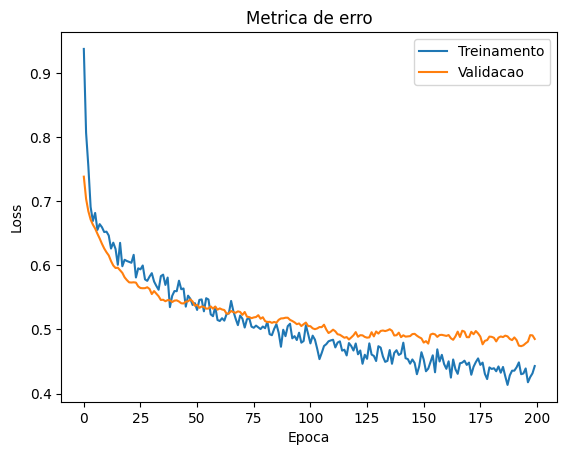


-> Loss_treino = 0.3921
-> Loss_val = 0.4852
-> Loss_val - Loss_treino = 0.0931

-> E_in = 0.1573
-> E_val = 0.1788
-> E_val - E_in = 0.0215

-> Acc_treino: 0.8427
-> Acc_val: 0.8212
-> Acc_treino - Acc_val = 0.0215


In [214]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Metrica de erro')
plt.ylabel('Loss')
plt.xlabel('Epoca')
plt.legend(['Treinamento', 'Validacao'])
plt.show()

loss_train, acc_train = model2.evaluate(X_treino, y_treino, batch_size=32, verbose=0)

loss_val, acc_val = model2.evaluate(X_val, y_val, batch_size=32, verbose=0)

e_in = 1 - acc_train
e_val = 1 - acc_val

print(f"\n-> Loss_treino = {loss_train:.4f}")
print(f"-> Loss_val = {loss_val:.4f}")
print(f"-> Loss_val - Loss_treino = {loss_val - loss_train:.4f}\n")

print(f"-> E_in = {e_in:.4f}")
print(f"-> E_val = {e_val:.4f}")
print(f"-> E_val - E_in = {e_val - e_in:.4f}\n")

print(f'-> Acc_treino: {acc_train:.4f}')
print(f'-> Acc_val: {acc_val:.4f}')
print(f"-> Acc_treino - Acc_val = {acc_train - acc_val:.4f}")

### Matriz de confusão

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


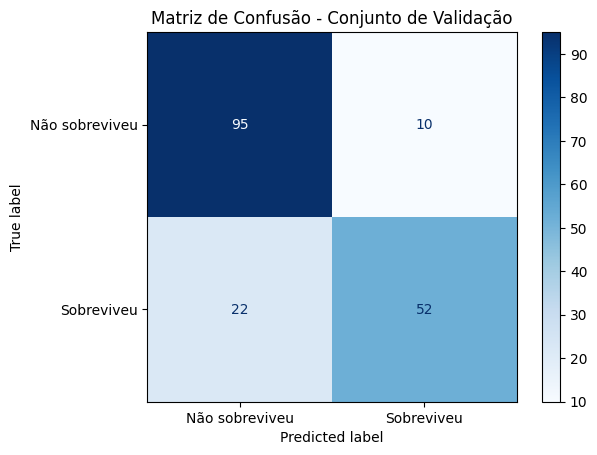

In [215]:
y_pred_val = (model2.predict(X_val) > 0.5).astype(int).flatten()

cm = confusion_matrix(y_val, y_pred_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Não sobreviveu', 'Sobreviveu'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão - Conjunto de Validação')
plt.show()

### Métricas de erro

In [216]:
acc = accuracy_score(y_val, y_pred_val)
prec = precision_score(y_val, y_pred_val)
rec = recall_score(y_val, y_pred_val)
f1 = f1_score(y_val, y_pred_val)

print(f"-> Accuracy: {acc:.4f}")
print(f"-> Precision: {prec:.4f}")
print(f"-> Recall: {rec:.4f}")
print(f"-> F1-score: {f1:.4f}\n")

print("Relatório de classificação completo:")
print(classification_report(y_val, y_pred_val, target_names=['Não sobreviveu', 'Sobreviveu']))

-> Accuracy: 0.8212
-> Precision: 0.8387
-> Recall: 0.7027
-> F1-score: 0.7647

Relatório de classificação completo:
                precision    recall  f1-score   support

Não sobreviveu       0.81      0.90      0.86       105
    Sobreviveu       0.84      0.70      0.76        74

      accuracy                           0.82       179
     macro avg       0.83      0.80      0.81       179
  weighted avg       0.82      0.82      0.82       179

